In [21]:
import rebound
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt 

In [22]:
#looked at this article https://academic.oup.com/mnras/article/380/2/479/1010413
#took the power spectrum of

In [491]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 6e-2
sim.add(m=1, hash = "Sun")
sim.add(m=9.54e-4,a=5.2,e=0.05,pomega = 0,M = 0,hash="Jupiter")
a_sat = 5.2*(2**(2/3))
sim.add(m=2.86e-4,a=a_sat*1.011,e=0.03,pomega = np.pi,M = 0,hash="Saturn")

sim.move_to_com()

In [492]:
sim.save_to_file("fft.bin", interval = 100, delete_file = True)

sim.integrate(1e6*2*np.pi)

snaps = rebound.Simulationarchive("fft.bin")

e_sat = np.array([snap.particles[2].e for snap in snaps])
long_peri_sat = np.array([snap.particles[2].pomega for snap in snaps])
lambda_sat = np.array([snap.particles[2].l for snap in snaps])
lambda_J = np.array([snap.particles[1].l for snap in snaps])
time_stamp = np.array([snap.t for snap in snaps])

In [493]:
h = e_sat*np.sin(long_peri_sat)
k = e_sat*np.cos(long_peri_sat)
z = k + h*1j

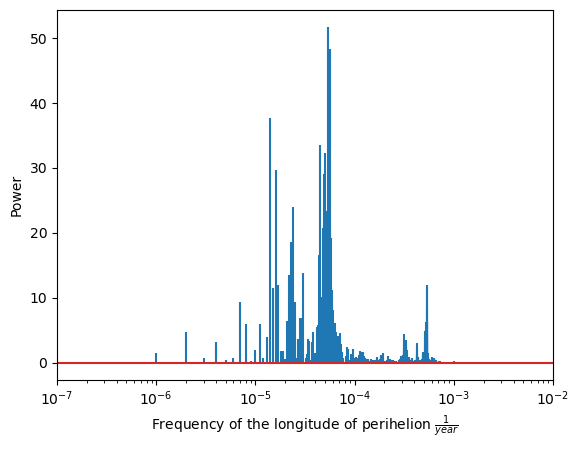

In [494]:
fs = 1/((time_stamp[1] - time_stamp[0])/(2*np.pi))

f, pxx = signal.periodogram(h,fs=fs,window='hann',scaling='density')

plt.stem(f,pxx,markerfmt = "none")
plt.xscale('log')
plt.ylabel("Power")
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{1}{year}$")
plt.xlim(1e-7,1e-2)
plt.show()

(1e-07, 0.01)

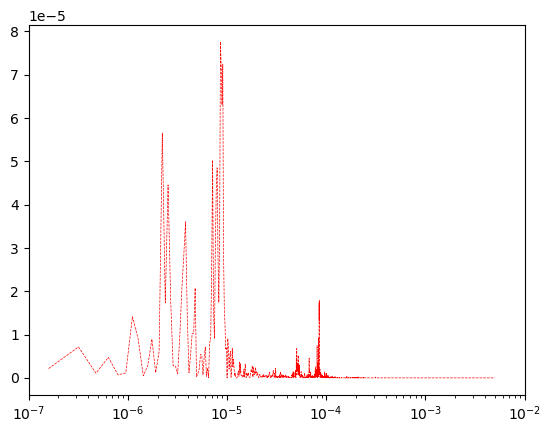

In [495]:
dt = time_stamp[1] - time_stamp[0]
fs = 1 / dt

f, pxx = signal.periodogram(h, fs=fs, 
                            window='hann', scaling='spectrum')
f = f[1:]
pxx = pxx[1:]
plt.plot(f,pxx,'r--',linewidth = 0.5)
plt.xscale('log')
plt.xlim(1e-7,1e-2)

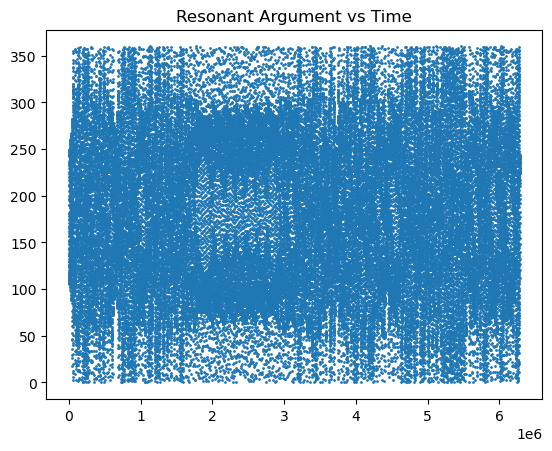

In [496]:
#resonant argument graph
res_arg = (2*lambda_sat - lambda_J - long_peri_sat) % (2*np.pi)
res_arg = res_arg*180/np.pi

plt.scatter(time_stamp,res_arg,s= 1)
plt.title("Resonant Argument vs Time")
plt.show()
plt.show()

In [269]:
#attempting stability
sim2 = rebound.Simulation()
sim2.integrator = "whfast"
sim2.dt = 6e-2
sim2.add(m=1, hash = "Sun")

a_sat2 = 5.2*((3/2)**(2/3))

sim2.add(m=9.5e-4, a=5.2, e=0.048, inc = 0, omega=0.257, f=0.0, hash = "Jupiter")
sim2.add(m=2.86e-4, a=a_sat2*0.97, e=0.056, inc=0, omega=1.613, f=0.0, hash = "Saturn")


sim2.move_to_com()

In [270]:
sim2.save_to_file("fft2.bin", interval = 1000, delete_file = True)

sim2.integrate(1e5*2*np.pi)

snaps2 = rebound.Simulationarchive("fft2.bin")

e_sat2 = np.array([snap2.particles[2].e for snap2 in snaps2])
long_peri_sat2 = np.array([snap2.particles[2].pomega for snap2 in snaps2])
time_stamp2 = np.array([snap2.t for snap2 in snaps2])
lambda_J2 = np.array([snap2.particles[1].l for snap2 in snaps2])
lambda_sat2 = np.array([snap2.particles[2].l for snap2 in snaps2])

In [271]:
h2 = e_sat2*np.sin(long_peri_sat2)
k2 = e_sat2*np.cos(long_peri_sat2)
z2 = k2 + h2*1j

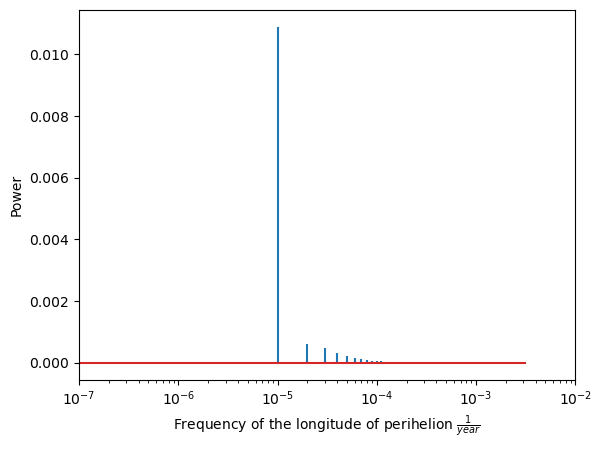

In [339]:
fs2 = 1/((time_stamp2[1] - time_stamp2[0])/(np.pi*2))

f2, pxx2 = signal.periodogram(h2,fs=fs2,window='hann',scaling='spectrum')

plt.stem(f2,pxx2,markerfmt = "none")
plt.xscale('log')
plt.ylabel("Power")
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{1}{year}$")
plt.xlim(1e-7,1e-2)
plt.show()

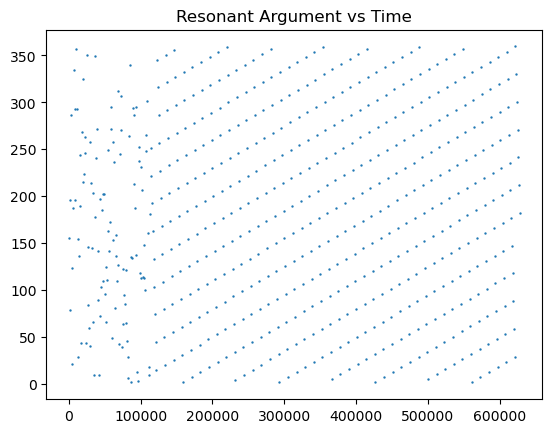

In [273]:
res_arg2 = (3*lambda_sat2 - 2*lambda_J2 - long_peri_sat2) % (2*np.pi)
res_arg2 = res_arg2*180/np.pi

plt.scatter(time_stamp2,res_arg2,s= 0.5)
plt.title("Resonant Argument vs Time")
plt.show()
plt.show()